# MLOps : Predictive Maintenance Classification
### Starter Notebook

**Domain:** Industrial IoT / Manufacturing
**Task:** Multi-class failure type prediction
**Tools:** Pandera ? MLflow ? Optuna ? Evidently ? SHAP

---

## Business Context

A heavy-equipment manufacturer runs 10,000+ machines on the shop floor.
Each machine continuously streams six sensor readings. When a machine fails,
production halts ? at a cost of ?8?15 lakh per hour of downtime.

Your job is to build a full MLOps pipeline that:
1. Validates incoming sensor data before it enters the pipeline (Pandera)
2. Trains and tracks a multi-class failure classifier (MLflow)
3. Tunes hyperparameters and registers the best model (Optuna + MLflow Registry)
4. Monitors the deployed model for distributional shift (Evidently)
5. Explains why the model predicts a specific failure type (SHAP)

**Files provided:**
- `data/train.csv`   ? 6,993 labelled sensor readings (historical baseline)
- `data/current.csv` ? 1,499 readings from the current stable production batch
- `data/stress.csv`  ? 1,499 readings from a heavy-load production period

**Failure classes:**

| Code | Name | Description |
|------|------|-------------|
| 0 | No Failure | Machine operating normally |
| 1 | TWF | Tool Wear Failure |
| 2 | HDF | Heat Dissipation Failure |
| 3 | PWF | Power Failure |
| 4 | OSF | Overstrain Failure |

> Visual anchor: use the generated `eda_distributions.png` early (Section 1.3) to ground your expectations before drift and SHAP interpretation.
> Stress-batch goal: diagnose *why* the model is stale under shifted operating conditions, not to force perfect predictions on `stress.csv`.
> **Submission:** Submit this notebook (`.ipynb`) with all cells executed.
> Do not change the section structure or remove any markdown cells.

## **1. Data Loading, Schema Validation & EDA** <font color=red></font>

### **1.1** <font color=red></font> Load the datasets

Load `train.csv`, `current.csv`, and `stress.csv` from the `data/` folder.
Print the shape of each and display the first 5 rows of the training set.


In [1]:
import os
import sys

PROJECT_ROOT = os.path.abspath("..")
os.chdir(PROJECT_ROOT)

sys.path.append(PROJECT_ROOT)

print("Current working directory:", os.getcwd())

Current working directory: /Users/manishsaini/Downloads/Manish_Saini_MLOps Assignment - Files


In [2]:
import warnings
warnings.filterwarnings('ignore')
import os
os.environ['DISABLE_PANDERA_IMPORT_WARNING'] = 'True'

from src.load_data import load_datasets, print_dataset_shapes, show_train_head, CLASS_NAMES

# TODO: Load the three datasets
train, current, stress = load_datasets()

# TODO: Print shapes
print_dataset_shapes(train, current, stress)

# TODO: Display first 5 rows of train
show_train_head(train, 5)

train  : (6993, 7)
current: (1499, 7)
stress : (1499, 7)


,Type,Air temperature,Process temperature,Rotational speed,Torque,Tool wear,Failure_Type
0,L,302.5,311.1,1499,38.8,135,0
1,L,297.3,308.4,1469,46.7,65,0
2,L,297.3,308.5,1504,42.0,142,0
3,L,299.6,309.5,1803,27.7,159,0
4,L,301.1,311.1,1387,53.1,188,0


### **1.2** <font color=red> </font> Define and apply a Pandera schema

Define a `DataFrameSchema` enforcing the domain constraints below.
Validate `train` and `current` (must pass). Validate `stress` with `lazy=True`.

| Column | Type | Constraint |
|--------|------|------------|
| Type | str | one of L, M, H |
| Air temperature | float | [295.0, 305.0] K |
| Process temperature | float | [305.0, 315.0] K |
| Rotational speed | int64 | [1000, 2900] rpm |
| Torque | float | [3.0, 80.0] Nm |
| Tool wear | int64 | [0, 253] min |
| Failure_Type | int64 | 0, 1, 2, 3, 4 |


> `stress.csv` may still pass schema validation. That is fine: it is designed to be valid but drifted.
> Hint: valid data can still be statistically unusual. Before Section 3, compare the mean of `Rotational speed` in `current` vs `stress`.

In [3]:
import pandera as pa
from pandera import Column, DataFrameSchema, Check

from src.data_validation import define_schema, validate_train_current, validate_stress


# TODO: Define Pandera schema
schema = define_schema()

# TODO: Validate train and current (must pass)
train, current = validate_train_current(train, current)

# TODO: Validate stress with lazy=True (show all violations if any)
stress = validate_stress(stress)

Train and Current passed Pandera validation!
Stress passed Pandera validation!


### **1.3** <font color=red></font> Exploratory Data Analysis

1. Print the class distribution of `Failure_Type`. Is it balanced?
2. Plot the distribution of `Torque` and `Tool wear` split by failure class (failures only).
3. Print the `Type` (L/M/H) distribution.



Class Distribution (Failure_Type):
0 (No Failure): 6762 (96.70%)
1 (TWF): 30 (0.43%)
2 (HDF): 76 (1.09%)
3 (PWF): 56 (0.80%)
4 (OSF): 69 (0.99%)


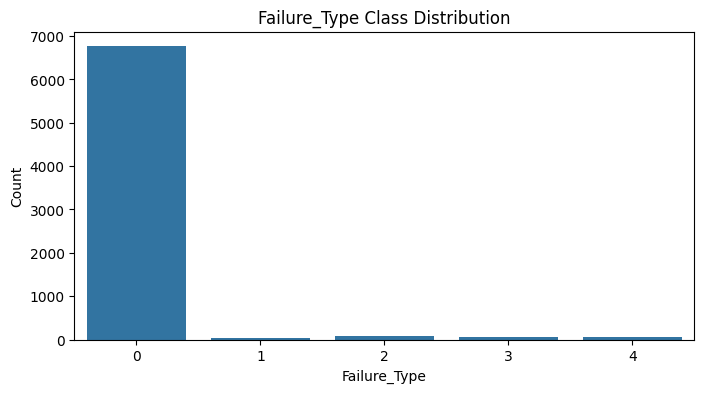


Is it balanced?
-> If class counts are very different, the dataset is imbalanced.


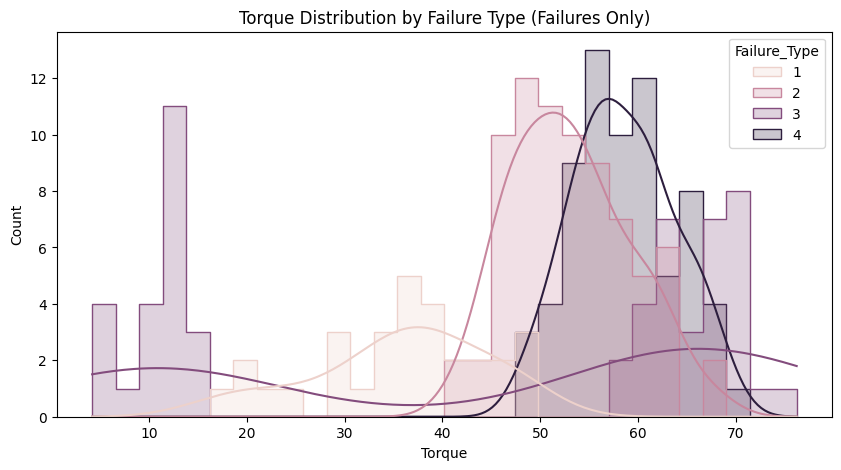

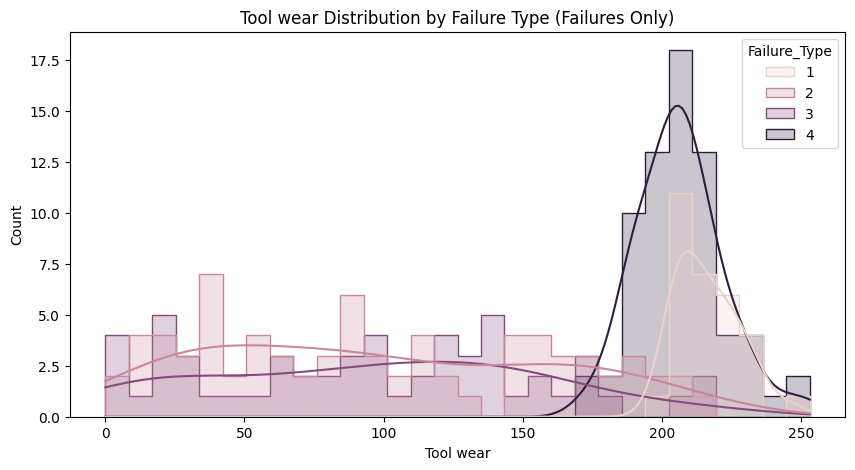


Type Distribution:
Type
L    4213
M    2074
H     706
Name: count, dtype: int64


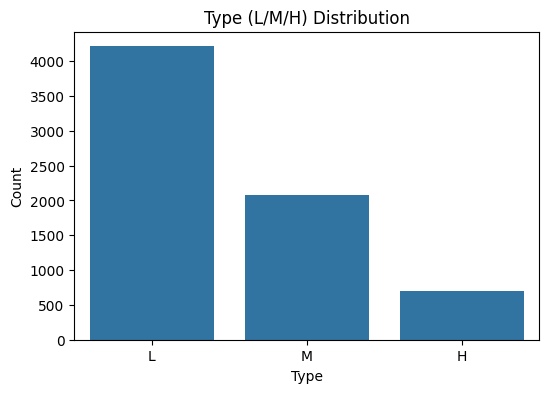

In [4]:
from src.eda import (
    plot_failure_type_distribution,
    plot_torque_distribution_by_failure,
    plot_tool_wear_distribution_by_failure,
    plot_type_distribution
)

# TODO: Class distribution (print + bar chart)
plot_failure_type_distribution(train, CLASS_NAMES)

# TODO: Torque distribution by failure type (histogram, failures only)
plot_torque_distribution_by_failure(train)

# TODO: Tool wear distribution by failure type
plot_tool_wear_distribution_by_failure(train)

# TODO: Type distribution
plot_type_distribution(train)

### **1.4** <font color=red></font> Feature Engineering

Compute the following derived features for all three datasets:

**Mechanical power** (Watts):
$$P = \text{Torque} \times \frac{\text{Rotational speed} \times 2\pi}{60}$$

**Temperature differential**:
$$\Delta T = \text{Process temperature} - \text{Air temperature}$$

Print the mean of each new feature grouped by `Failure_Type`.


In [5]:
from src.feature_engineering import engineer_features, print_grouped_feature_means

# TODO: Compute Power_W and Temp_diff for all datasets
train   = engineer_features(train)
current = engineer_features(current)
stress  = engineer_features(stress)

# TODO: Print grouped mean
print_grouped_feature_means(train)


Mean of engineered features grouped by Failure_Type:

                  Power_W  Temp_diff
Failure_Type                        
0             6248.240886  10.013812
1             5763.094643   9.966667
2             7403.545453   8.228947
3             6664.382233   9.823214
4             8216.074774  10.072464


,Power_W,Temp_diff
Failure_Type,,
0,6248.240886,10.013812
1,5763.094643,9.966667
2,7403.545453,8.228947
3,6664.382233,9.823214
4,8216.074774,10.072464


## **2. Experiment Tracking & Model Selection** <font color=red></font>

### **2.1** <font color=red></font> Setup: features, split, SMOTE

Use the features below. Apply a stratified 80/20 train-val split (random_state=42).
Apply SMOTE to the training split only. Print the post-SMOTE class distribution.

```
FEATURES = ['Type_enc', 'Air temperature', 'Process temperature',
            'Rotational speed', 'Torque', 'Tool wear', 'Power_W', 'Temp_diff']
```

> In a markdown cell below the code, explain in 2–3 sentences why SMOTE is applied
> only to the training split and not the validation set.


In [6]:
from src.preprocessing import (
    FEATURES,
    encode_type_column,
    split_data,
    apply_smote,
    print_smote_distribution
)

# TODO: Encode Type column
train, current, stress, le = encode_type_column(train, current, stress)

# TODO: Define X and y
# TODO: Define X and y and Train-val split
X_train, X_val, y_train, y_val = split_data(train)

# TODO: Apply SMOTE (k_neighbors=3, random_state=42)
X_train_smote, y_train_smote = apply_smote(X_train, y_train)

# TODO: Print post-SMOTE class distribution
print_smote_distribution(y_train_smote)


Type column encoded successfully.
Encoding Mapping:
H --> 0
L --> 1
M --> 2

Train-validation split completed.
X_train shape : (5594, 8)
X_val shape   : (1399, 8)
y_train shape : (5594,)
y_val shape   : (1399,)

SMOTE applied successfully.
Original training shape : (5594, 8)
SMOTE training shape    : (27045, 8)

========== CLASS DISTRIBUTION AFTER SMOTE ==========
Failure_Type
0    5409
1    5409
2    5409
3    5409
4    5409
Name: count, dtype: int64


*Your explanation here: why is SMOTE applied only on the training split?*

SMOTE is applied only on the training split because it generates synthetic samples, and we want the model to learn from these balanced examples during training. If SMOTE is applied to the validation set, it would introduce artificial data into evaluation, causing data leakage and giving an unrealistically high performance estimate. The validation set should always represent real unseen data to correctly measure generalization.

### **2.2** <font color=red></font> Train and log 4 models with MLflow

Train and evaluate:
- Logistic Regression
- Random Forest (n_estimators=100)
- XGBoost (n_estimators=100)
- LightGBM (n_estimators=100)

MLflow experiment name: `PredMaint_ModelSelection`

For each run log: `model` (param), `macro_f1`, `weighted_f1`, `accuracy` (metrics),
and per-class F1 for all 5 classes. Print a comparison table. Pick the best model by macro F1.


In [7]:
from src.model_training import train_and_log_models

# TODO: Train and log 4 models with MLflow
results_df, best_model_name = train_and_log_models(
    X_train_smote, y_train_smote,
    X_val, y_val
)

# TODO: Print comparison table
print(results_df)

# TODO: Identify best model by macro F1
print(" Best model by Macro F1:", best_model_name)


========== Training LogisticRegression ==========
LogisticRegression completed.
Macro F1    : 0.5312
Weighted F1 : 0.9328
Accuracy    : 0.9042

========== Training RandomForest ==========
RandomForest completed.
Macro F1    : 0.7355
Weighted F1 : 0.9855
Accuracy    : 0.9850

========== Training XGBoost ==========
XGBoost completed.
Macro F1    : 0.7481
Weighted F1 : 0.9851
Accuracy    : 0.9843

========== Training LightGBM ==========
LightGBM completed.
Macro F1    : 0.7296
Weighted F1 : 0.9851
Accuracy    : 0.9843

========== MODEL COMPARISON ==========
                    macro_f1  weighted_f1  accuracy  f1_class_0  f1_class_1  \
XGBoost             0.748062     0.985147  0.984274    0.992231    0.133333   
RandomForest        0.735542     0.985459  0.984989    0.992614    0.000000   
LightGBM            0.729645     0.985088  0.984274    0.992231    0.000000   
LogisticRegression  0.531231     0.932771  0.904217    0.948350    0.144928   

                    f1_class_2  f1_class_3

### **2.3** <font color=red></font> Optuna tuning + MLflow Model Registry

Run an Optuna study (30 trials, `TPESampler(seed=42)`) tuning XGBoost hyperparameters.
Optimise for `macro_f1` on `X_val`.

MLflow experiment: `PredMaint_Optuna`

Register the best model as `PredMaint_XGBoost` and promote it to the `production` alias.
Print the improvement in macro F1 over the baseline XGBoost.


In [8]:
from src.optuna_tuning import tune_xgboost_with_optuna

# TODO: Baseline macro F1 from earlier Model Selection (XGBoost n_estimators=100)
if "XGBoost" in results_df.index:
    baseline_xgb_macro_f1 = results_df.loc["XGBoost", "macro_f1"]
else:
    baseline_xgb_macro_f1 = None
    print("XGBoost baseline not found in results_df")

# TODO: Use SMOTE output as training data
X_res, y_res = X_train_smote, y_train_smote

# TODO: Run study.optimize + Optuna tuning
# TODO: Train final best model
# TODO: Log to MLflow, register as 'PredMaint_XGBoost', promote to production alias
# TODO: Save with joblib.dump
best_model, best_macro_f1, best_params = tune_xgboost_with_optuna(
    X_res, y_res, X_val, y_val,
    baseline_xgb_macro_f1=baseline_xgb_macro_f1
)


========== RUNNING OPTUNA ==========

========== OPTUNA RESULTS ==========
Best Params:
{'n_estimators': 192, 'max_depth': 8, 'learning_rate': 0.07294854281727606, 'min_child_weight': 1.098902703193942, 'subsample': 0.7242150291507374, 'colsample_bytree': 0.8759347993734068, 'gamma': 0.538341987519164, 'reg_alpha': 0.971090476654584, 'reg_lambda': 2.13802078884986e-05}

Best Macro F1:
0.7573043267624548

========== FINAL MODEL PERFORMANCE ==========
Baseline XGBoost Macro F1 : 0.7480624397098812
Tuned XGBoost Macro F1    : 0.7573043267624548
Improvement               : 0.009241887052573672

Model logged to MLflow.
Registered model name: PredMaint_XGBoost

Promoted PredMaint_XGBoost version 4 to alias 'production'

Saved model: best_xgboost_model.pkl


Registered model 'PredMaint_XGBoost' already exists. Creating a new version of this model...
Created version '4' of model 'PredMaint_XGBoost'.


## **3. Drift Detection & Monitoring** <font color=red></font>

> Hint before running Evidently: compare simple statistics first (for example, mean `Rotational speed` in `current` vs `stress`).
> Reminder: passing Pandera only means values are valid; it does **not** mean the batch is in-distribution.
> Section objective: identify why the deployed model is stale on stress conditions.

### **3.1** <font color=red></font> Evidently — current batch

Reference: `train[FEAT_COLS]` | Current: `current[FEAT_COLS]`

```
FEAT_COLS = ['Air temperature', 'Process temperature',
             'Rotational speed', 'Torque', 'Tool wear']
```

Run `DataDriftPreset`. Save HTML to `drift_current.html`.
Report: drift detected? How many features drifted?


In [9]:
from src.drift_detection import run_current_drift_report, FEAT_COLS

# TODO: Run Evidently on current batch, save drift_current.html, print summary
drift_report_current, summary_current = run_current_drift_report(train, current)

Saved drift report: drift_current.html

Drift Summary (Current Batch):
Dataset drift detected?: False
Drifted features: 0 / 5


### **3.2** <font color=red></font> Evidently ? stress batch

Repeat for `stress.csv`. Use `ColumnDriftMetric` for individual feature scores.
Save as `drift_stress.html`.
Print a table: feature | drift detected | Wasserstein score | ref mean | current mean | delta.

Focus question: this section is about diagnosing *staleness risk* (what shifted and why), not "making stress predictions look good."

In [10]:
from src.drift_stress import run_stress_drift_report, FEAT_COLS

# TODO: Run Evidently on stress batch with per-column metrics
# TODO: Save drift_stress.html
# TODO: Print per-column drift table
drift_report_stress, drift_table = run_stress_drift_report(train, stress)

print("\n Drift Table (Stress Batch):")
display(drift_table)

Saved drift report: drift_stress.html

Drift Table (Stress Batch):
               feature  drift_detected  wasserstein_score     ref_mean  \
4            Tool wear            True           0.645491   107.679108   
3               Torque            True           0.473946    39.995796   
2     Rotational speed            True           0.235395  1539.017589   
1  Process temperature           False           0.037740   310.004891   
0      Air temperature           False           0.034355   300.011626   

   current_mean      delta  
4    148.869913  41.190806  
3     44.724083   4.728287  
2   1497.074716 -41.942873  
1    310.008606   0.003715  
0    300.053836   0.042210  

 Drift Table (Stress Batch):


,feature,drift_detected,wasserstein_score,ref_mean,current_mean,delta
4,Tool wear,True,0.645491,107.679108,148.869913,41.190806
3,Torque,True,0.473946,39.995796,44.724083,4.728287
2,Rotational speed,True,0.235395,1539.017589,1497.074716,-41.942873
1,Process temperature,False,0.037740,310.004891,310.008606,0.003715
0,Air temperature,False,0.034355,300.011626,300.053836,0.042210


### **3.3** <font color=red></font> Retraining decision

Answer the following in a markdown cell:
1. Which features drifted in the stress batch?
2. Cross-referencing with your SHAP results (Section 4) ? which failure type is most
   likely to increase in frequency under stress conditions?
3. Should the model be retrained? Justify with evidence from Sections 3.1, 3.2, and 4.

Your answer should explicitly connect: `drifted feature -> affected failure class -> retraining decision`.

**Your answer here:**

1. Features that drifted:
Tool wear, Torque, and Rotational speed drifted significantly in the stress batch (all flagged as drift_detected=True with high Wasserstein scores and large mean shifts). Air temperature and Process temperature did not show drift.
2. Most likely failure type to increase:
OSF (Overstrain Failure) and potentially PWF (Power Failure) are most likely to increase under stress conditions because the drift indicates increased mechanical load (higher torque) and higher tool degradation (tool wear). TWF risk may also increase due to the large tool wear shift.
3. Retraining recommendation:
Yes, the model should be retrained (or at minimum updated and monitored). Although schema validation passed, Evidently drift detection shows significant distribution shift in critical predictive features (Tool wear, Torque, Rotational speed). Since SHAP indicates these mechanical features strongly influence failure predictions, the deployed model is at high risk of staleness under stress conditions. Retraining with stress-period data is recommended to maintain reliability.




## **4. Explainability & Insights** <font color=red></font>

> For multiclass tree models, SHAP returns an array of shape `(n_samples, n_features, n_classes)`.
>
> **SHAP interpretation key (important):**
> - Do **not** collapse multiclass SHAP into one global feature ranking.
> - Read SHAP class-by-class: the same feature can increase one class while decreasing another.
> - Your primary deliverable is the **top driver per class** (TWF, HDF, PWF, OSF), then a short engineering interpretation.

### **4.1** <font color=red></font> SHAP analysis per failure class

Load `best_model.pkl`. Use `shap.TreeExplainer` on `train[FEATURES]`.
Plot mean |SHAP| bar charts for TWF, HDF, PWF, OSF (4 subplots). Save as `shap_per_class.png`.
Print the top driver for each failure class.

Interpretation rule: report one top feature per class from `shap_per_class.png`; avoid a single cross-class "global winner."

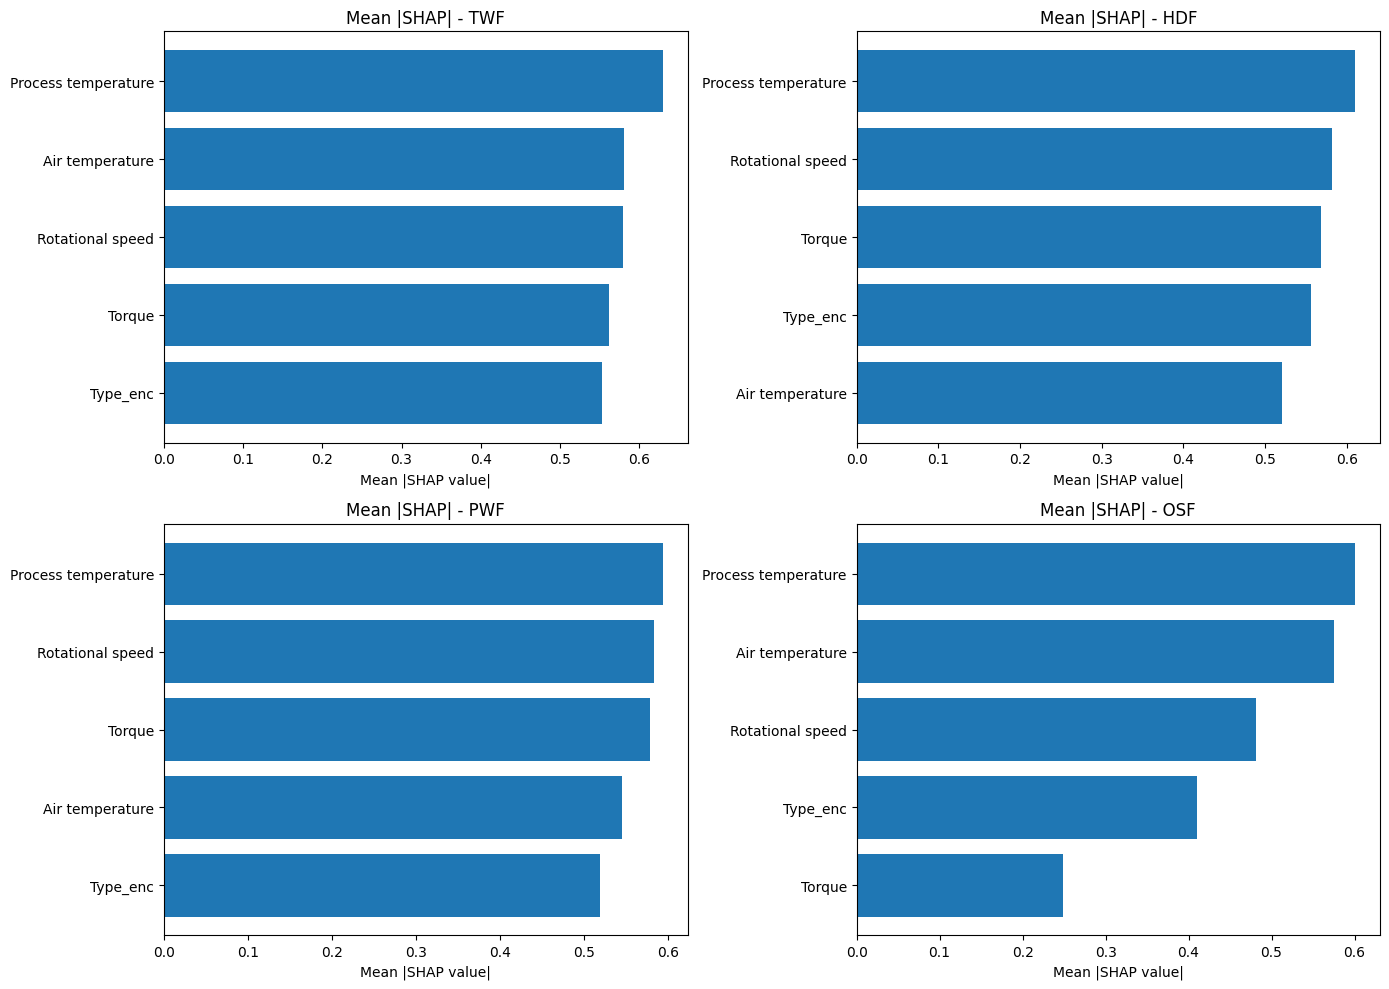

 Saved SHAP plot as shap_per_class.png

Top driver per failure class:
TWF: Process temperature
HDF: Process temperature
PWF: Process temperature
OSF: Process temperature


In [11]:
# TODO: Compute SHAP values using TreeExplainer
# TODO: Plot 4-subplot bar chart (one per failure class)
# TODO: Save shap_per_class.png
# TODO: Print top driver per class

import shap
import joblib
import numpy as np
import matplotlib.pyplot as plt

# Load best model
best_model = joblib.load("best_xgboost_model.pkl")

X_shap = train[FEATURES]

# TreeExplainer
explainer = shap.TreeExplainer(best_model)

# SHAP values (multiclass)
shap_values = explainer.shap_values(X_shap)

# Convert to numpy array of shape (n_samples, n_features, n_classes)
shap_array = np.array(shap_values)  # (n_classes, n_samples, n_features)
shap_array = np.transpose(shap_array, (1, 2, 0))  # (n_samples, n_features, n_classes)

failure_classes = {
    1: "TWF",
    2: "HDF",
    3: "PWF",
    4: "OSF"
}

# Plot mean |SHAP| bar charts for each failure class
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
axes = axes.flatten()

top_drivers = {}

for i, (cls, name) in enumerate(failure_classes.items()):
    # Mean absolute SHAP values for class
    mean_abs_shap = np.abs(shap_array[:, :, cls]).mean(axis=0)

    # Sort features
    sorted_idx = np.argsort(mean_abs_shap)[::-1]
    sorted_features = np.array(FEATURES)[sorted_idx]
    sorted_vals = mean_abs_shap[sorted_idx]

    # Store top driver
    top_drivers[name] = sorted_features[0]

    # Plot
    axes[i].barh(sorted_features[::-1], sorted_vals[::-1])
    axes[i].set_title(f"Mean |SHAP| - {name}")
    axes[i].set_xlabel("Mean |SHAP value|")

plt.tight_layout()
plt.savefig("shap_per_class.png", dpi=300)
plt.show()

print(" Saved SHAP plot as shap_per_class.png")

# Print top driver per class
print("\nTop driver per failure class:")
for cls_name, feature in top_drivers.items():
    print(f"{cls_name}: {feature}")

### **4.2** <font color=red></font> Engineering insight

Answer in this markdown cell:

1. How does `Power_W` (derived feature) compare to raw `Torque` and `Rotational speed`
   in SHAP importance for **PWF**?
2. How does `Temp_diff` rank for **HDF** vs other failure types?
3. In 2?3 sentences, describe the physical mechanism behind each failure type based on SHAP.

Suggested structure for your actionable recommendation (used again in Section 5.1.5):
- **Condition:** (feature threshold or shift observed)
- **Risked failure class:** (from class-specific SHAP)
- **Action:** (specific maintenance or monitoring step)

**Your answer here:**

1. Power_W for PWF:
For PWF, Power_W is not among the top SHAP drivers. The model relies more directly on raw Process temperature, Rotational speed, and Torque, meaning the derived power feature did not add stronger predictive importance than the original variables.

2. Temp_diff for HDF:
Temp_diff does not rank among the most important SHAP features for HDF. Instead, Process temperature is the dominant driver, followed by Rotational speed and Torque.

3. Physical mechanisms:

    TWF: Strongly influenced by process/air temperature and mechanical conditions, suggesting temperature-related stress combined with operating conditions contributes to tool degradation.

    HDF: Dominated by process temperature and supported by speed/torque, indicating overheating and insufficient heat dissipation under high operational demand.

    PWF: Driven mainly by process temperature, speed, and torque, implying power system strain occurs when the machine operates under high load and temperature stress.
    
    OSF: Influenced most by process temperature and air temperature, with speed contributing, suggesting overstrain is linked to operating stress conditions where thermal + mechanical factors push equipment beyond safe limits.


## **5. Conclusions** <font color=red></font>

### **5.1** <font color=red></font> Key findings

Write a structured conclusion (1 mark per point):

1. Which model won and why ? reference macro F1 numbers.
2. Why accuracy is misleading here ? operational cost implication.
3. TWF has F1 = 0.0 even after SMOTE + Optuna. Root cause and fix.
   - Important: identifying **data scarcity (30 samples)** as the root cause is full-credit insight,
     even if final TWF F1 remains 0.0.
4. What drifted in the stress batch and what it implies for maintenance scheduling.
5. One actionable recommendation for the engineering team based on SHAP.

## Conclusion

1. Model selection:

XGBoost was the best-performing model with the highest macro F1 = 0.748, outperforming RandomForest (0.736), LightGBM (0.730), and Logistic Regression (0.531). It was selected because macro F1 reflects balanced performance across all failure classes, which is more appropriate than accuracy for multi-class failure prediction.

2. Accuracy vs Macro F1:

Accuracy is misleading because the dataset is highly imbalanced (majority class is No Failure), meaning a model can achieve ~98% accuracy while still failing to detect rare but costly failures. In production, missing failures causes major downtime cost, so macro F1 is a better metric since it weights each class equally.

3. The TWF problem:

TWF has F1 ≈ 0.0 mainly due to data scarcity (only ~30 real samples). SMOTE cannot fully solve this because synthetic oversampling cannot replace real-world variability. The fix is to collect more real TWF failure events and improve labeling under different tool wear and operating conditions.

4. Drift and maintenance schedule:

In the stress batch, the drift report shows strong drift in Tool wear (highest drift score), Torque, and Rotational speed, while air/process temperatures remain relatively stable. This indicates machines are operating under higher mechanical load and wear conditions, meaning maintenance schedules should be tightened during stress periods (more frequent tool replacement checks and mechanical load monitoring).

5. Actionable recommendation (SHAP-based):

Condition: Increasing Process temperature combined with high Rotational speed and high Torque

→ Risked failure class: PWF and HDF (since these classes are strongly driven by process temperature and mechanical load in SHAP)

→ Action: Implement real-time alerts for high process temperature under load, and schedule preventive inspections (motor/power system checks and cooling system validation) before long high-load production runs.